k investigates the monetary side of orders: how payment methods relate to order value and completion, and how shipping costs affect delivery speed.

                         order_count  avg_order_value  completion_rate  \
payment_methods                                                          
credit_card                    74259       166.946479         0.971222   
boleto                         19784       145.034435         0.970026   
voucher                         1621       114.387588         0.924121   
debit_card                      1527       142.724158         0.971840   
credit_card, voucher            1127       146.021446         0.973381   
voucher, credit_card            1118       155.770304         0.969589   
not_defined                        3         0.000000         0.000000   
credit_card, debit_card            1       152.820000         1.000000   

                         payment_risk_index  
payment_methods                              
credit_card                        4.804328  
boleto                             4.347221  
voucher                            8.679626  
debit_card                   

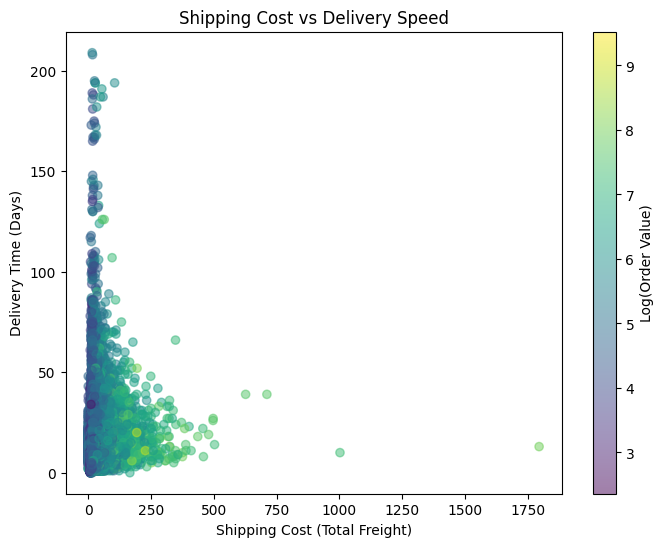

                               order_id  total_freight  delivery_time_days  \
50863  8339b608be0d84fca9d8da68b58332c3         165.90                 0.0   
72759  bb5a519e352b45b714192a02ffe25681          16.46                 0.0   
11467  1d893dd7ca5f77ebf5f59f0d2017eee0          15.21                 0.0   
80564  cf4659487be50c0c317cff3564c4a840        1794.96                13.0   
94702  f3c6775ba3d2d9fe2826f93b71f12008          12.48                 0.0   
26085  434cecee7d1a65fc65358a632b6f725f          11.86                 0.0   
1936   04f6cdae6a85ade2864cd5fc811fb9ba         123.06                 1.0   
14064  2455cbeb73fd04b170ca2504662f95ce        1002.29                10.0   
82424  d3ca7b82c922817b06e5ca21165c5ea2           9.51                 0.0   
22011  38c1e3d4ed6a13cd0cf612d4c09766e9           9.45                 0.0   

       cost_efficiency_index  
50863            1659.000000  
72759             164.600000  
11467             152.100000  
80564            

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load orders dataset
orders = pd.read_csv(
    r"C:\Users\Admin\OneDrive\Desktop\olist-capstone-project\data\processed\olist_master_order_level.csv",
    parse_dates=["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
)

# --- Payment analysis ---
payment_stats = (
    orders.groupby("payment_methods")
    .agg(
        order_count=("order_id", "nunique"),
        avg_order_value=("total_payment_value", "mean"),
        completion_rate=("order_status", lambda x: (x=="delivered").mean())
    )
    .sort_values("order_count", ascending=False)
)

# Payment Risk Index
payment_stats["payment_risk_index"] = (1 - payment_stats["completion_rate"]) * payment_stats["avg_order_value"]

print(payment_stats)

# --- Shipping cost vs delivery speed ---
plt.figure(figsize=(8,6))
plt.scatter(
    orders["total_freight"],
    orders["delivery_time_days"],
    alpha=0.5,
    c=np.log1p(orders["total_payment_value"]),
    cmap="viridis"
)
plt.colorbar(label="Log(Order Value)")
plt.xlabel("Shipping Cost (Total Freight)")
plt.ylabel("Delivery Time (Days)")
plt.title("Shipping Cost vs Delivery Speed")
plt.show()

# Optional: Shipping Cost Efficiency Index
orders["cost_efficiency_index"] = orders["total_freight"] / (orders["delivery_time_days"] + 0.1)  # avoid divide by zero
top_efficiency_orders = orders.sort_values("cost_efficiency_index", ascending=False).head(10)
print(top_efficiency_orders[["order_id", "total_freight", "delivery_time_days", "cost_efficiency_index"]])
